# Diffusion-based inverse design of bimetallic N<sub>2</sub>-activation catalystsReproduction and repair of the supporting-information code from `ja5c14652_si_001.zip`(`DD_model_code`), run end-to-end in the **CompChem** conda environment.**Pipeline**| Stage | Original file | What it does ||---|---|---|| 1 | `JY_data_dfilling_nonsite.xlsx` | DFT database: 28 monometallic + ~1368 bimetallic surface sites, 30 features each || 2 | `Pred_Model_train.py` | Random-Forest forward model `features -> N_ads`; ships pre-trained as `Nads_opt.pkl` || 3 | `dd_module.py` | DDPM (denoising diffusion) generative model over the 30-dim feature vector, guided by the N_ads model || 4 | `reverse_gen.py` | Reverse (ancestral) sampling to emit new candidate feature vectors |**Target property:** `N_ads`, the nitrogen adsorption energy (eV). Both too-weak and too-strongN binding kill N<sub>2</sub> activation, so the guidance term pushes generated candidates toward`TARGET_NADS` (0 eV by default, matching the original code).---## Bugs in the published code, and how they are fixed here1. **`VECTOR_SIZE = 18` but the data has 30 features.** `iloc[:, 11:41]` is 30 columns and   `Nads_opt.pkl` reports `n_features_in_ = 30`. The diffusion model could never have been fed   the real data. -> `VECTOR_SIZE = 30`.2. **`schedule['alpha'][t]` / `schedule['alpha_bar'][t]`** (`dd_module.py:82-83`) - `schedule` is a   `DiffusionSchedule` *object*, not a dict, and it has no `alpha`/`alpha_bar` attributes.   `TypeError` on the first batch. -> `tf.gather(schedule.alphas_cumprod, t)`.3. **`pickle.load` inside `@tf.function`** (`dd_module.py:91`) - re-reads a 77 MB forest from disk   on every batch, inside a traced graph. -> loaded once, outside.4. **The RF guidance term has no gradient.** A scikit-learn `RandomForestRegressor` is not a TF op;   `tape.gradient` returns `None` through it, so `lambda_cond * loss_condition` contributes nothing   even after fixing (2) and (3). -> a small differentiable **Keras surrogate** of `N_ads` is trained   here and used for guidance; the original RF is kept as an *independent* evaluator of the   generated candidates (so the screening metric is never the same model that did the guiding).5. **No feature scaling in the diffusion loop.** `Nads_opt.pkl` was fitted on `StandardScaler`-   transformed inputs, but `dd_module.py` feeds raw values. -> the whole generative loop runs in   standardized space; the scaler is re-fitted with the exact split/seed of `Pred_Model_train.py`.6. **`reverse_gen.py:84-86` uses undefined globals** `alphas`, `alphas_cumprod`, `betas`   (`NameError`). -> `schedule.*`.7. **`Pred_Model_train.py` cannot run as shipped:** it reads `data_dfilling.xlsx` (not in the zip;   the actual file is `JY_data_dfilling_nonsite.xlsx`) and imports `outlier_management` and   `plot_parameters`, neither of which is included. -> filename fixed, `remove_outliers`   reimplemented, plotting inlined.8. **Generated vectors are not physically valid** - nothing in the original code maps a raw 30-dim   sample back to an alloy. -> a decoder is added (Section 7) that snaps composition to a real   element pair and rebuilds elemental descriptors from a lookup table.9. **`EPOCHS = 50` massively undertrains the diffusion model.** 878 training rows at batch 128 is   7 steps/epoch, so 50 epochs = **350 gradient steps** at `lr = 1e-4`. Measured here: the denoising   loss is still ~0.31 (vs 1.0 for predicting nothing) and the reverse process diverges - samples come   out with std 1.95 and range [-9.5, 11.7] where the real standardized data has std 1.00 and range   [-3.1, 5.1]. -> `EPOCHS = 2000`, `lr = 5e-4` (14k steps, ~100 s on CPU): loss 0.11, sample std 0.92,   range [-3.4, 6.4]. See the diagnostic in Section 5b.10. **`lambda_cond = 10.0` on an unclipped $\hat{x}_0$ destroys the generator.** At large $t$,   $\hat{x}_0 = (x_t - \sqrt{1-\bar\alpha_t}\,\epsilon_\theta)/\sqrt{\bar\alpha_t}$ divides by   $\sqrt{\bar\alpha_t}\to 0$, so the property term sees wildly out-of-range inputs and dominates the   gradient. Run as published (with bugs 1-5 fixed) it drives samples to ~$10^4$ in standardized units   and collapses all 200 samples onto a single alloy. -> $\hat{x}_0$ is clipped, the term is weighted by   $\bar\alpha_t$ so it only acts where $\hat{x}_0$ is meaningful, and property targeting is moved to   **sampling-time classifier guidance**, which is both stable and steerable (Section 6).

In [1]:
# ============================ 0. Setup ============================
import os, sys, pickle, time, warnings, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_style("white")

# ---- paths ----
# point N2DD_DATA_DIR at the unzipped DD_model_code folder (supporting information, not redistributed)
DATA_DIR   = Path(os.environ.get("N2DD_DATA_DIR", Path.cwd() / "data"))
WORK_DIR   = Path.cwd()
CKPT_DIR   = WORK_DIR / "checkpoints"
OUT_DIR    = WORK_DIR / "outputs"
CKPT_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_XLSX  = DATA_DIR / "JY_data_dfilling_nonsite.xlsx"
NADS_PKL   = DATA_DIR / "Nads_opt.pkl"

# ---- hyperparameters (originals kept, VECTOR_SIZE corrected 18 -> 30) ----
VECTOR_SIZE   = 30          # was 18 in dd_module.py        <-- BUG 1
TIMESTEPS     = 1000
BATCH_SIZE    = 128
EPOCHS        = 2000        # was 50 (= 350 gradient steps) <-- BUG 9
LEARNING_RATE = 5e-4        # was 1e-4                      <-- BUG 9
EMBEDDING_DIM = 128
SEED          = 71          # matches Pred_Model_train.py / dd_module.py

# ---- inverse-design target ----
TARGET_NADS    = 0.0        # eV; original code pushed the condition toward 0
LAMBDA_COND    = 0.0        # training-time property loss; original 10.0 diverges <-- BUG 10
X0_CLIP        = 5.0        # clip on the x0 estimate inside the property term
GUIDANCE_SCALE = 10.0       # sampling-time classifier guidance (Section 6)

np.random.seed(SEED)
tf.random.set_seed(SEED)

print("python     :", sys.version.split()[0])
print("tensorflow :", tf.__version__)
print("data file  :", DATA_XLSX, "|", DATA_XLSX.exists())
print("rf model   :", NADS_PKL, "|", NADS_PKL.exists())


python     : 3.9.23
tensorflow : 2.15.1
data file  : <REPO>\DD_extracted\DD_model_code\JY_data_dfilling_nonsite.xlsx | True
rf model   : <REPO>\DD_extracted\DD_model_code\Nads_opt.pkl | True


python     : 3.9.23
tensorflow : 2.15.1
data file  : <REPO>\DD_extracted\DD_model_code\JY_data_dfilling_nonsite.xlsx | True
rf model   : <REPO>\DD_extracted\DD_model_code\Nads_opt.pkl | True


---## 1. Load the DFT database`data_mono` = 28 pure-metal reference sites, `data_bi` = bimetallic sites (fcc/hcp, A- or B-terminated,compositions A:B = 1:1 and 3:1). Column blocks (from the original `.iloc` slices):* **mono**: target = col 8 (`N_ads`), features = cols 9:39* **bi**:   target = col 10 (`N_ads`), features = cols 11:41Both resolve to the same 30 features: 16 element-fraction one-hots (`frac_Ag` ... `frac_W`),5 paired elemental descriptors for A and B (atomic radius, spatial extent, ionization energy,electron affinity, electronegativity) and 4 local d-band fillings (`filling_a` ... `filling_d`).The `N_ads` window `(-2, 1) eV` is the original preprocessing filter - the raw column runs up to+737 eV from unconverged calculations.

In [2]:
# ============================ 1. Data ============================
data_mono = pd.read_excel(DATA_XLSX, sheet_name="data_mono")
data_bi   = pd.read_excel(DATA_XLSX, sheet_name="data_bi")

print("raw shapes:", data_mono.shape, data_bi.shape)

# --- original preprocessing: drop failed calculations ---
data_bi   = data_bi.dropna(axis=0)
data_mono = data_mono[(data_mono["N_ads"] < 1) & (data_mono["N_ads"] > -2)]
data_bi   = data_bi[(data_bi["N_ads"] < 1) & (data_bi["N_ads"] > -2)]
print("after N_ads filter:", data_mono.shape, data_bi.shape)

FEATURE_NAMES = list(data_bi.columns[11:41])
assert FEATURE_NAMES == list(data_mono.columns[9:39]), "mono/bi feature blocks disagree"
assert len(FEATURE_NAMES) == VECTOR_SIZE

mono_train_data_X = data_mono.iloc[:, 9:39].to_numpy(dtype=np.float64)
mono_train_data_Y = data_mono.iloc[:, 8].to_numpy(dtype=np.float64)
bi_train_data_X   = data_bi.iloc[:, 11:41].to_numpy(dtype=np.float64)
bi_train_data_Y   = data_bi.iloc[:, 10].to_numpy(dtype=np.float64)

FRAC_COLS = [c for c in FEATURE_NAMES if c.startswith("frac_")]
ELEMENTS  = [c.replace("frac_", "") for c in FRAC_COLS]
DESC_COLS = [c for c in FEATURE_NAMES if not c.startswith("frac_")]

print(f"\nfeatures ({len(FEATURE_NAMES)}):")
print("  composition :", FRAC_COLS)
print("  descriptors :", DESC_COLS)
print(f"\nmono X {mono_train_data_X.shape}  bi X {bi_train_data_X.shape}")
print(f"N_ads (bi): min {bi_train_data_Y.min():.3f}  max {bi_train_data_Y.max():.3f}  mean {bi_train_data_Y.mean():.3f} eV")

raw shapes: (28, 55) (1368, 57)
after N_ads filter: (20, 55) (1098, 57)

features (30):
  composition : ['frac_Ag', 'frac_Au', 'frac_Co', 'frac_Cr', 'frac_Cu', 'frac_Fe', 'frac_Ir', 'frac_Mo', 'frac_Ni', 'frac_Os', 'frac_Pd', 'frac_Pt', 'frac_Re', 'frac_Rh', 'frac_Ru', 'frac_W']
  descriptors : ['radius_A', 'radius_B', 'spatial_extent_A', 'spatial_extent_B', 'ionization_energy_A', 'ionization_energy_B', 'electron_affinity_A', 'electron_affinity_B', 'electronegativity_A', 'electronegativity_B', 'filling_a', 'filling_b', 'filling_c', 'filling_d']

mono X (20, 30)  bi X (1098, 30)
N_ads (bi): min -1.985  max 0.972  mean -0.575 eV


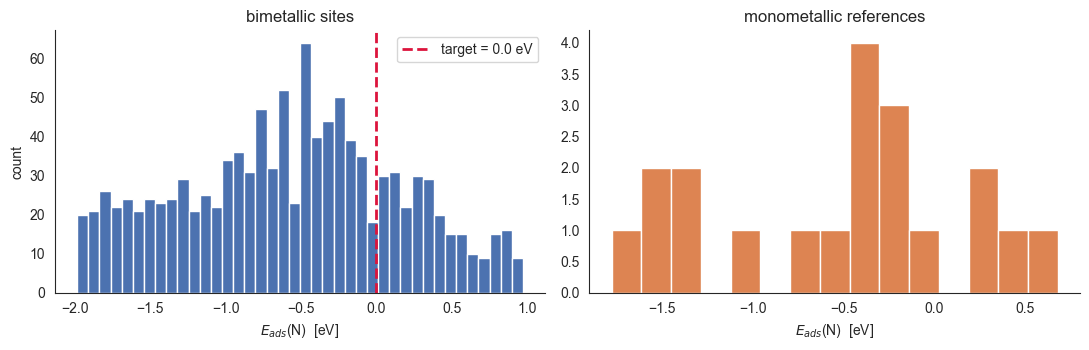

In [3]:
# distribution of the target
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].hist(bi_train_data_Y, bins=40, color="#4C72B0", edgecolor="w")
ax[0].axvline(TARGET_NADS, color="crimson", ls="--", lw=2, label=f"target = {TARGET_NADS} eV")
ax[0].set_xlabel("$E_{ads}$(N)  [eV]"); ax[0].set_ylabel("count"); ax[0].set_title("bimetallic sites")
ax[0].legend()
ax[1].hist(mono_train_data_Y, bins=15, color="#DD8452", edgecolor="w")
ax[1].set_xlabel("$E_{ads}$(N)  [eV]"); ax[1].set_title("monometallic references")
sns.despine(fig); plt.tight_layout(); plt.show()

---## 2. Forward model: N adsorption energy`Pred_Model_train.py` splits the bimetallic set 80/20 (`random_state=71`), appends the monometallicdata to the training half, standardizes with a scaler fitted on **all** rows, then fits a RandomForest. Reproducing that split exactly here regenerates the same `StandardScaler` that`Nads_opt.pkl` expects - without it the pre-trained forest gets garbage inputs.

In [3]:
# ============================ 2. Split + scaler (exact repro of Pred_Model_train.py) ============================
t_size = 0.2
bi_train_x, bi_validation_x, bi_train_y, bi_validation_y = train_test_split(
    bi_train_data_X, bi_train_data_Y, test_size=t_size, random_state=SEED)

train_data_x = np.append(mono_train_data_X, bi_train_x, axis=0)
train_data_y = np.append(mono_train_data_Y, bi_train_y, axis=0)
val_data_x   = bi_validation_x.copy()
val_data_y   = bi_validation_y.copy()

x_summary = np.append(train_data_x, val_data_x, axis=0)
scaler  = StandardScaler().fit(x_summary)
X_train = scaler.transform(train_data_x)
X_val   = scaler.transform(val_data_x)

print("train:", X_train.shape, " val:", X_val.shape)

train: (898, 30)  val: (220, 30)


In [4]:
# ---- load the published optimized forest ----
with open(NADS_PKL, "rb") as f:
    rf_nads = pickle.load(f)

print(type(rf_nads).__name__, "| n_features_in_ =", rf_nads.n_features_in_,
      "| n_estimators =", rf_nads.n_estimators, "| max_depth =", rf_nads.max_depth)

y_train_pred = rf_nads.predict(X_train)
y_val_pred   = rf_nads.predict(X_val)
print(f"\nTraining MAE : {mean_absolute_error(train_data_y, y_train_pred):.4f} eV   R2 = {r2_score(train_data_y, y_train_pred):.4f}")
print(f"Testing  MAE : {mean_absolute_error(val_data_y,   y_val_pred):.4f} eV   R2 = {r2_score(val_data_y, y_val_pred):.4f}")
print("\n(a low test MAE here confirms the scaler was reproduced correctly)")

RandomForestRegressor | n_features_in_ = 30 | n_estimators = 1000 | max_depth = 20

Training MAE : 0.1062 eV   R2 = 0.9111
Testing  MAE : 0.2154 eV   R2 = 0.7948

(a low test MAE here confirms the scaler was reproduced correctly)



Training MAE : 0.1062 eV   R2 = 0.9111
Testing  MAE : 0.2154 eV   R2 = 0.7948

(a low test MAE here confirms the scaler was reproduced correctly)


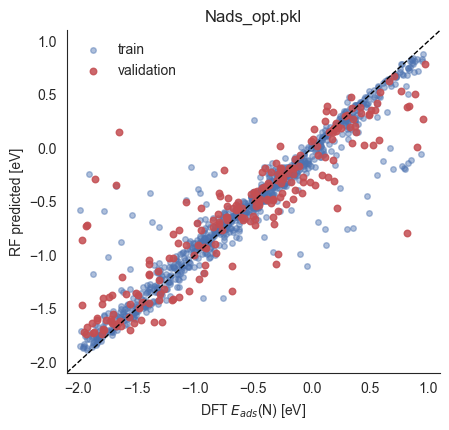

In [5]:
# parity plot for the pre-trained forward model
fig, ax = plt.subplots(figsize=(4.6, 4.4))
ax.scatter(train_data_y, y_train_pred, s=16, alpha=.45, label="train", color="#4C72B0")
ax.scatter(val_data_y,   y_val_pred,   s=22, alpha=.85, label="validation", color="#C44E52")
lims = [-2.1, 1.1]
ax.plot(lims, lims, "k--", lw=1)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("DFT $E_{ads}$(N) [eV]"); ax.set_ylabel("RF predicted [eV]")
ax.set_title("Nads_opt.pkl"); ax.legend(frameon=False)
sns.despine(fig); plt.tight_layout(); plt.show()

### 2b. (optional) Re-train the forward model from scratchThis is `Pred_Model_train.py` with its three blockers fixed: the correct filename, an inlined`remove_outliers` (the shipped code imports a module that is not in the zip), and the plottingimport dropped. The grid search is 80 fits x 5 folds x up to 2000 trees - several minutes on CPU -so it is **off by default**. The rest of the notebook uses the published `Nads_opt.pkl`.

In [6]:
RETRAIN_RF  = False    # set True to re-run Pred_Model_train.py end-to-end
RUN_GRID    = False    # set True for the full GridSearchCV (slow)

def remove_outliers(X, y, model, n_sigma=2.0):
    # Reimplementation of the missing `outlier_management.remove_outliers`:
    # drop points whose prediction residual exceeds n_sigma standard deviations, i.e. the
    # DFT entries the forest cannot reconcile with the rest of the database.
    resid = y - model.predict(X)
    keep  = np.abs(resid - resid.mean()) <= n_sigma * resid.std()
    return X[keep], y[keep]

if RETRAIN_RF:
    from sklearn.model_selection import GridSearchCV
    num_trees = 48
    original_model = RandomForestRegressor(n_estimators=num_trees, random_state=42).fit(X_train, train_data_y)
    print(f"baseline  train MAE {mean_absolute_error(train_data_y, original_model.predict(X_train)):.4f}"
          f" | val MAE {mean_absolute_error(val_data_y, original_model.predict(X_val)):.4f}")

    X_train_f, Y_train_f = remove_outliers(X_train, train_data_y, original_model)
    X_test_f,  Y_test_f  = remove_outliers(X_val,   val_data_y,   original_model)
    print(f"outlier removal: train {len(X_train)} -> {len(X_train_f)}, val {len(X_val)} -> {len(X_test_f)}")

    new_model = RandomForestRegressor(n_estimators=num_trees, random_state=42).fit(X_train_f, Y_train_f)
    print(f"filtered  train MAE {mean_absolute_error(Y_train_f, new_model.predict(X_train_f)):.4f}"
          f" | val MAE {mean_absolute_error(Y_test_f, new_model.predict(X_test_f)):.4f}")

    if RUN_GRID:
        param_grid = {"bootstrap":[True], "max_depth":[20,30,40,50], "max_features":[6,8,10,12],
                      "min_samples_leaf":[1], "min_samples_split":[2],
                      "n_estimators":[100,500,1000,1500,2000]}
        gs = GridSearchCV(new_model, param_grid, n_jobs=-1, verbose=1).fit(X_train_f, Y_train_f)
        best = gs.best_estimator_
        print("best params:", gs.best_params_)
        print(f"optimized train MAE {mean_absolute_error(Y_train_f, best.predict(X_train_f)):.4f}"
              f" | val MAE {mean_absolute_error(Y_test_f, best.predict(X_test_f)):.4f}")
        with open(OUT_DIR / "Nads_opt_retrained.pkl", "wb") as f:
            pickle.dump(best, f)
else:
    print("skipped - using the published Nads_opt.pkl")

skipped - using the published Nads_opt.pkl


---## 3. Differentiable surrogate for the guidance termThe original loss is$$\mathcal{L} = \underbrace{\lVert \epsilon - \epsilon_\theta(x_t,t)\rVert^2}_{\text{denoising}}  + \lambda_{\text{cond}}\,\underbrace{\lVert f(\hat{x}_0) - E^{\text{target}}\rVert^2}_{\text{property guidance}}$$with $f$ = the Random Forest. A forest is piecewise-constant and lives outside the TF graph, so$\partial \mathcal{L}_{\text{cond}} / \partial \theta$ is identically zero (in TF, literally `None`)and the guidance term is inert. Replacing $f$ with a small MLP trained on the same data makes theterm do what the paper describes. The forest is then held back as an **independent** judge of thegenerated candidates in Section 8.

In [7]:
# ============================ 3. Surrogate N_ads model (differentiable) ============================
def build_surrogate():
    return keras.Sequential([
        keras.Input(shape=(VECTOR_SIZE,)),
        layers.Dense(256, activation="swish"),
        layers.Dense(256, activation="swish"),
        layers.Dense(128, activation="swish"),
        layers.Dense(1),
    ], name="nads_surrogate")

surrogate = build_surrogate()
surrogate.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])

hist = surrogate.fit(X_train, train_data_y,
                     validation_data=(X_val, val_data_y),
                     epochs=400, batch_size=64, verbose=0,
                     callbacks=[keras.callbacks.EarlyStopping(patience=60, restore_best_weights=True)])

sur_val = surrogate.predict(X_val, verbose=0).ravel()
print(f"surrogate  val MAE = {mean_absolute_error(val_data_y, sur_val):.4f} eV   R2 = {r2_score(val_data_y, sur_val):.4f}")
print(f"forest     val MAE = {mean_absolute_error(val_data_y, y_val_pred):.4f} eV   R2 = {r2_score(val_data_y, y_val_pred):.4f}")
surrogate.trainable = False       # frozen during diffusion training




surrogate  val MAE = 0.2069 eV   R2 = 0.8400
forest     val MAE = 0.2154 eV   R2 = 0.7948


surrogate  val MAE = 0.2095 eV   R2 = 0.8302
forest     val MAE = 0.2154 eV   R2 = 0.7948


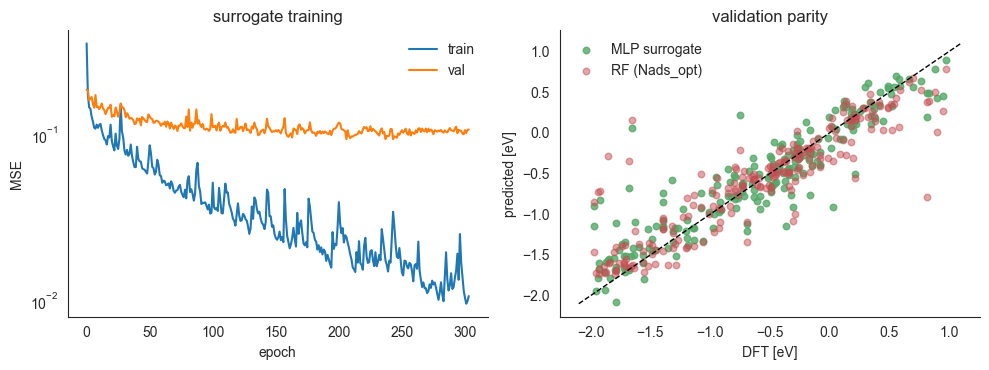

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
ax[0].plot(hist.history["loss"], label="train"); ax[0].plot(hist.history["val_loss"], label="val")
ax[0].set_yscale("log"); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("MSE"); ax[0].legend(frameon=False)
ax[0].set_title("surrogate training")
ax[1].scatter(val_data_y, sur_val, s=22, color="#55A868", alpha=.8, label="MLP surrogate")
ax[1].scatter(val_data_y, y_val_pred, s=22, color="#C44E52", alpha=.5, label="RF (Nads_opt)")
ax[1].plot([-2.1,1.1], [-2.1,1.1], "k--", lw=1)
ax[1].set_xlabel("DFT [eV]"); ax[1].set_ylabel("predicted [eV]"); ax[1].legend(frameon=False)
ax[1].set_title("validation parity")
sns.despine(fig); plt.tight_layout(); plt.show()

---## 4. Diffusion modelStandard DDPM over the 30-dim standardized feature vector: a linear $\beta$ schedule($10^{-4} \to 0.02$, 1000 steps), sinusoidal timestep embedding, and an MLP denoiser$\epsilon_\theta(x_t, t)$ - the architecture from `dd_module.py`, with the vector size corrected.

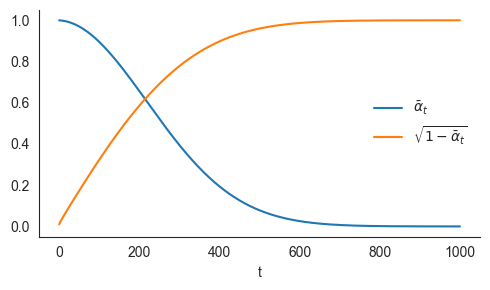

In [11]:
# ============================ 4. Diffusion schedule ============================
class DiffusionSchedule:
    def __init__(self, timesteps, beta_start=1e-4, beta_end=0.02):
        self.timesteps = timesteps
        self.betas   = np.linspace(beta_start, beta_end, timesteps, dtype=np.float32)
        self.alphas  = 1.0 - self.betas
        self.alphas_cumprod = np.cumprod(self.alphas)
        self.sqrt_alphas_cumprod = np.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = np.sqrt(1.0 - self.alphas_cumprod)
        # tf copies for use inside @tf.function
        self.tf_alphas_cumprod = tf.constant(self.alphas_cumprod, tf.float32)
        self.tf_sqrt_ac        = tf.constant(self.sqrt_alphas_cumprod, tf.float32)
        self.tf_sqrt_1mac      = tf.constant(self.sqrt_one_minus_alphas_cumprod, tf.float32)

schedule = DiffusionSchedule(TIMESTEPS)

fig, ax = plt.subplots(figsize=(5,3))
ax.plot(schedule.alphas_cumprod, label=r"$\bar{\alpha}_t$")
ax.plot(schedule.sqrt_one_minus_alphas_cumprod, label=r"$\sqrt{1-\bar{\alpha}_t}$")
ax.set_xlabel("t"); ax.legend(frameon=False); sns.despine(fig); plt.tight_layout(); plt.show()

In [12]:
# ============================ 4b. Denoiser ============================
def sinusoidal_embedding(t, embedding_dim=EMBEDDING_DIM):
    half_dim = embedding_dim // 2
    emb = np.log(10000) / (half_dim - 1)
    emb = np.exp(np.arange(half_dim) * -emb)
    emb = tf.cast(t[:, None], tf.float32) * emb[None, :]
    return tf.concat([tf.sin(emb), tf.cos(emb)], axis=-1)

def build_denoising_model():
    x_input = keras.Input(shape=(VECTOR_SIZE,))
    t_input = keras.Input(shape=(), dtype=tf.int32)

    t_emb = layers.Lambda(lambda t: sinusoidal_embedding(t))(t_input)
    t_emb = layers.Dense(128, activation="swish")(t_emb)
    t_emb = layers.Dense(128, activation="swish")(t_emb)

    x = layers.Dense(128, activation="swish")(x_input)
    x = layers.Concatenate()([x, t_emb])
    x = layers.Dense(256, activation="swish")(x)
    x = layers.Dense(256, activation="swish")(x)
    x = layers.Dense(VECTOR_SIZE)(x)
    return keras.Model([x_input, t_input], x, name="denoiser")

model = build_denoising_model()
optimizer = keras.optimizers.Adam(LEARNING_RATE)
mse_loss  = keras.losses.MeanSquaredError()
model.summary()

Model: "denoiser"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None,)]                    0         []                            
                                                                                                  
 lambda (Lambda)             (None, 128)                  0         ['input_3[0][0]']             
                                                                                                  
 input_2 (InputLayer)        [(None, 30)]                 0         []                            
                                                                                                  
 dense_4 (Dense)             (None, 128)                  16512     ['lambda[0][0]']              
                                                                                           

__________________________________________________________________________________________________


 Layer (type)                Output Shape                 Param #   Connected to                  


 input_3 (InputLayer)        [(None,)]                    0         []                            


 lambda (Lambda)             (None, 128)                  0         ['input_3[0][0]']             


...

 dense_9 (Dense)             (None, 30)                   7710      ['dense_8[0][0]']             


Total params: 176286 (688.62 KB)


Trainable params: 176286 (688.62 KB)


Non-trainable params: 0 (0.00 Byte)


__________________________________________________________________________________________________


In [13]:
# ============================ 4c. Forward diffusion + training step ============================
def add_noise(x0, t, noise, schedule):
    sqrt_ac   = tf.gather(schedule.tf_sqrt_ac,   t)
    sqrt_1mac = tf.gather(schedule.tf_sqrt_1mac, t)
    return sqrt_ac[:, None] * x0 + sqrt_1mac[:, None] * noise

target_const = tf.constant(TARGET_NADS, tf.float32)

@tf.function
def train_step(x0):
    batch_size = tf.shape(x0)[0]
    t     = tf.random.uniform((batch_size,), 0, TIMESTEPS, dtype=tf.int32)
    noise = tf.random.normal(tf.shape(x0))
    noisy_x = add_noise(x0, t, noise, schedule)

    with tf.GradientTape() as tape:
        predicted_noise = model([noisy_x, t], training=True)
        loss_denoise = mse_loss(noise, predicted_noise)

        if LAMBDA_COND > 0.0:
            # --- BUG 2 fixed: schedule is an object, gather from its tf tensors ---
            alpha_bar_t         = tf.gather(schedule.tf_alphas_cumprod, t)[:, None]
            sqrt_alpha_bar_t    = tf.sqrt(alpha_bar_t)
            sqrt_one_minus_ab_t = tf.sqrt(1.0 - alpha_bar_t)
            # --- BUG 10 fixed: clip; 1/sqrt(alpha_bar) blows up at large t ---
            x0_pred = tf.clip_by_value(
                (noisy_x - sqrt_one_minus_ab_t * predicted_noise) / sqrt_alpha_bar_t,
                -X0_CLIP, X0_CLIP)

            # --- BUGS 3+4 fixed: differentiable surrogate, loaded once, graph-native ---
            pred_condition = surrogate(x0_pred, training=False)
            # weight by alpha_bar_t: only trust x0_pred where the sample is still nearly clean
            loss_condition = (tf.reduce_sum(alpha_bar_t * tf.square(pred_condition - target_const))
                              / (tf.reduce_sum(alpha_bar_t) + 1e-8))
        else:
            loss_condition = tf.constant(0.0)

        loss = loss_denoise + LAMBDA_COND * loss_condition

    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss, loss_denoise, loss_condition

---## 5. Train the diffusion modelTrained on the standardized bimetallic training split (the same rows the forward model saw), sogenerated samples live in the same space the property models were fitted in.

In [14]:
# ============================ 5. Training ============================
X_diff = scaler.transform(bi_train_x).astype(np.float32)
print("diffusion training set:", X_diff.shape)

train_dataset = tf.data.Dataset.from_tensor_slices(X_diff).shuffle(1000).batch(BATCH_SIZE)

checkpoint = tf.train.Checkpoint(optimizer=optimizer, model=model)
checkpoint_manager = tf.train.CheckpointManager(checkpoint, str(CKPT_DIR), max_to_keep=3)
if checkpoint_manager.latest_checkpoint:
    checkpoint.restore(checkpoint_manager.latest_checkpoint)
    print(f"Restored from {checkpoint_manager.latest_checkpoint}")
else:
    print("Starting training from scratch.")

diffusion training set: (878, 30)
Restored from <REPO>\N2_catalyst_DD\checkpoints\ckpt-12


In [15]:
history = {"loss": [], "denoise": [], "cond": []}
t0 = time.time()
for epoch in range(EPOCHS):
    tot = den = con = 0.0; nb = 0
    for x_batch in train_dataset:
        l, ld, lc = train_step(x_batch)
        tot += float(l); den += float(ld); con += float(lc); nb += 1
    history["loss"].append(tot/nb); history["denoise"].append(den/nb); history["cond"].append(con/nb)
    if (epoch+1) % 200 == 0 or epoch == 0:
        checkpoint_manager.save()
        print(f"Epoch {epoch+1:>5} | Loss: {tot/nb:.6f} | denoise: {den/nb:.6f} | cond: {con/nb:.6f}")
checkpoint_manager.save()
print(f"\ntrained {EPOCHS} epochs ({EPOCHS*nb} gradient steps) in {time.time()-t0:.1f} s")
print("denoising loss of 1.0 == predicting no noise at all; well below 1.0 means the model learned something")

Epoch     1 | Loss: 0.108243 | denoise: 0.108243 | cond: 0.000000
Epoch   200 | Loss: 0.109544 | denoise: 0.109544 | cond: 0.000000
Epoch   400 | Loss: 0.119084 | denoise: 0.119084 | cond: 0.000000
Epoch   600 | Loss: 0.113326 | denoise: 0.113326 | cond: 0.000000
Epoch   800 | Loss: 0.104275 | denoise: 0.104275 | cond: 0.000000
Epoch  1000 | Loss: 0.101626 | denoise: 0.101626 | cond: 0.000000
Epoch  1200 | Loss: 0.107615 | denoise: 0.107615 | cond: 0.000000
Epoch  1400 | Loss: 0.104938 | denoise: 0.104938 | cond: 0.000000
Epoch  1600 | Loss: 0.089032 | denoise: 0.089032 | cond: 0.000000
Epoch  1800 | Loss: 0.108751 | denoise: 0.108751 | cond: 0.000000
Epoch  2000 | Loss: 0.095641 | denoise: 0.095641 | cond: 0.000000

trained 2000 epochs (14000 gradient steps) in 106.1 s
denoising loss of 1.0 == predicting no noise at all; well below 1.0 means the model learned something


Epoch   200 | Loss: 0.192109 | denoise: 0.192109 | cond: 0.000000


Epoch   400 | Loss: 0.186451 | denoise: 0.186451 | cond: 0.000000


Epoch   600 | Loss: 0.167273 | denoise: 0.167273 | cond: 0.000000


Epoch   800 | Loss: 0.143064 | denoise: 0.143064 | cond: 0.000000


...

Epoch  1200 | Loss: 0.136702 | denoise: 0.136702 | cond: 0.000000


Epoch  1400 | Loss: 0.129249 | denoise: 0.129249 | cond: 0.000000


Epoch  1600 | Loss: 0.109001 | denoise: 0.109001 | cond: 0.000000


Epoch  1800 | Loss: 0.127001 | denoise: 0.127001 | cond: 0.000000


Epoch  2000 | Loss: 0.110932 | denoise: 0.110932 | cond: 0.000000

trained 2000 epochs (14000 gradient steps) in 106.1 s
denoising loss of 1.0 == predicting no noise at all; well below 1.0 means the model learned something


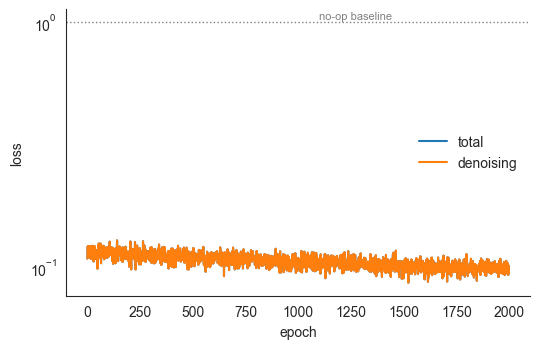

In [16]:
fig, ax = plt.subplots(figsize=(5.5,3.6))
ax.plot(history["loss"],    label="total")
ax.plot(history["denoise"], label="denoising")
if LAMBDA_COND > 0:
    ax.plot(np.array(history["cond"])*LAMBDA_COND, label=f"{LAMBDA_COND:g} x condition")
ax.axhline(1.0, color="grey", ls=":", lw=1)
ax.text(EPOCHS*0.55, 1.03, "no-op baseline", color="grey", fontsize=8)
ax.set_yscale("log"); ax.set_xlabel("epoch"); ax.set_ylabel("loss"); ax.legend(frameon=False)
sns.despine(fig); plt.tight_layout(); plt.show()

---## 6. Reverse sampling`reverse_gen.py`, with `schedule.*` restored (BUG 6), plus **classifier guidance** - this is whereproperty targeting actually happens (BUG 10). At each step the predicted noise is shifted along theproperty gradient in the standard form$$\hat{\epsilon} \leftarrow \epsilon_\theta(x_t,t) + s\,\sqrt{1-\bar\alpha_t}\;  \nabla_{x_t}\big(f_\phi(x_t)-E^{\text{target}}\big)^2$$which keeps the guidance strength commensurate with the noise level at every $t$. The gradient isnorm-clipped so a single pathological sample cannot blow up the batch. `x_init` is the knob theoriginal README means by *"the starting point is free to change"* - pass a perturbed known catalystto explore around it instead of starting from pure noise.

In [17]:
# ============================ 6. Ancestral sampling ============================
GRAD_CLIP_NORM = 20.0

@tf.function
def _grad_condition(x, target):
    with tf.GradientTape() as tape:
        tape.watch(x)
        loss = tf.reduce_sum(tf.square(surrogate(x, training=False) - target))
    g = tape.gradient(loss, x)
    return tf.clip_by_norm(g, GRAD_CLIP_NORM, axes=[1])

def sample(model, schedule, num_samples, target=TARGET_NADS, guidance_scale=0.0, x_init=None, seed=None):
    # DDPM reverse process. x_init lets you start from a perturbed known catalyst
    # instead of pure noise ("the starting point is free to change").
    if seed is not None:
        tf.random.set_seed(seed)
    x = tf.random.normal((num_samples, VECTOR_SIZE)) if x_init is None else tf.cast(x_init, tf.float32)
    tgt = tf.constant(target, tf.float32)

    for t_inv in range(TIMESTEPS - 1, -1, -1):
        t = tf.constant([t_inv] * num_samples, dtype=tf.int32)
        predicted_noise = model([x, t], training=False)

        # --- classifier guidance, scaled by the noise level at this step ---
        if guidance_scale > 0.0:
            predicted_noise += (guidance_scale
                                * schedule.sqrt_one_minus_alphas_cumprod[t_inv]
                                * _grad_condition(x, tgt))

        alpha_t         = schedule.alphas[t_inv]
        alpha_cumprod_t = schedule.alphas_cumprod[t_inv]
        beta_t          = schedule.betas[t_inv]

        coef1 = 1 / np.sqrt(alpha_t)
        coef2 = beta_t / np.sqrt(1 - alpha_cumprod_t)

        z = tf.random.normal((num_samples, VECTOR_SIZE)) if t_inv > 0 else tf.zeros_like(x)
        x = coef1 * (x - coef2 * predicted_noise) + np.sqrt(beta_t) * z
    return x.numpy()

N_SAMPLES = 200

t0 = time.time()
generated_raw = sample(model, schedule, N_SAMPLES, target=TARGET_NADS,
                       guidance_scale=GUIDANCE_SCALE, seed=SEED)
print(f"generated {generated_raw.shape} in {time.time()-t0:.1f} s")
print("\nfirst 3 raw (standardized) samples:")
print(np.round(generated_raw[:3], 3))

generated (200, 30) in 21.2 s

first 3 raw (standardized) samples:
[[-0.367 -0.276 -0.144 -0.235 -0.358 -0.289 -0.301 -0.204  1.85  -0.341
  -0.335 -0.287 -0.351  2.103 -0.468 -0.336 -1.532  0.056 -1.386  0.096
  -0.477 -0.819  0.143  0.015 -0.593  0.722  0.203  0.977  0.461 -0.246]
 [-0.354 -0.309 -0.396  1.354 -0.358 -0.339 -0.354 -0.347 -0.424 -0.385
   3.998 -0.347 -0.365 -0.396 -0.47  -0.319  0.498 -1.057 -0.154 -0.389
   0.57  -2.116 -0.711 -0.795  0.463 -1.825  0.962  1.626 -3.012  1.203]
 [-0.322 -0.23  -0.154 -0.184 -0.266 -0.271 -0.371 -0.297  1.225  2.354
  -0.304 -0.323 -0.446 -0.246 -0.357 -0.139 -1.352 -0.058 -1.309  0.683
  -0.393  0.669 -0.041 -0.02  -0.614  0.419 -1.364  0.955  1.176  0.309]]


### 6b. Is the reverse process actually converged?The single most useful sanity check for a diffusion model on tabular data: **unguided** samples mustreproduce the spread of the training distribution. In standardized space real data has `std = 1.00`by construction. A model trained for the original 50 epochs emits `std ~ 1.95` with a range of`[-9.5, 11.7]` - visibly diverged, and the reason the published settings produce garbage.

                          real (train)       generated
overall std                      0.998           0.943
min                             -3.083          -2.947
max                              5.059           5.957
mean |per-dim mean|              0.015           0.075
mean per-dim std                 0.997           0.931


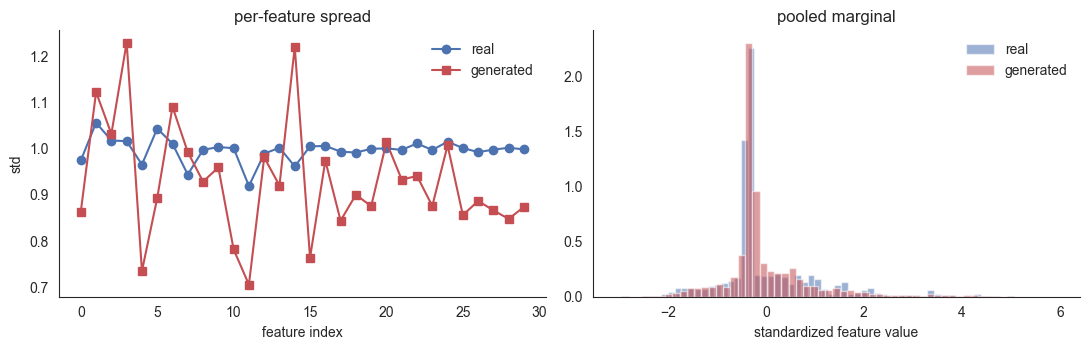

In [18]:
# ============================ 6b. Convergence check ============================
probe = sample(model, schedule, 200, guidance_scale=0.0, seed=SEED)

print(f"{'':22}{'real (train)':>16}{'generated':>16}")
print(f"{'overall std':22}{X_diff.std():>16.3f}{probe.std():>16.3f}")
print(f"{'min':22}{X_diff.min():>16.3f}{probe.min():>16.3f}")
print(f"{'max':22}{X_diff.max():>16.3f}{probe.max():>16.3f}")
print(f"{'mean |per-dim mean|':22}{np.abs(X_diff.mean(0)).mean():>16.3f}{np.abs(probe.mean(0)).mean():>16.3f}")
print(f"{'mean per-dim std':22}{X_diff.std(0).mean():>16.3f}{probe.std(0).mean():>16.3f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(X_diff.std(0), "o-", label="real", color="#4C72B0")
ax[0].plot(probe.std(0), "s-", label="generated", color="#C44E52")
ax[0].set_xlabel("feature index"); ax[0].set_ylabel("std"); ax[0].legend(frameon=False)
ax[0].set_title("per-feature spread")
ax[1].hist(X_diff.ravel(), bins=60, density=True, alpha=.55, label="real", color="#4C72B0")
ax[1].hist(probe.ravel(),  bins=60, density=True, alpha=.55, label="generated", color="#C44E52")
ax[1].set_xlabel("standardized feature value"); ax[1].legend(frameon=False)
ax[1].set_title("pooled marginal")
sns.despine(fig); plt.tight_layout(); plt.show()

---## 7. Decoding a sample into an actual alloyA raw sample is 30 floats and is not a material. The 16 composition channels must reduce to twoelements with a physically available ratio, and the 10 elemental descriptors are *functions of thosetwo elements* - they cannot be chosen freely. The decoder therefore:1. inverse-transforms to physical units;2. takes the two largest composition channels -> element pair (A, B), snapping the ratio to the   nearest of the ratios present in the database (50:50 or 75:25);3. overwrites the 10 A/B descriptors with the true tabulated values for those elements;4. keeps the 4 generated `filling_a..d` values (the genuinely new degrees of freedom - the local   d-band filling of the adsorption ensemble), clipped to the observed range;5. records the distance from the generated filling vector to the closest real site of the same   element pair, as a plausibility check.

In [19]:
# ============================ 7. Decoder ============================
# element -> tabulated descriptors, harvested from the database itself
elem_desc = {}
for _, r in data_bi.iterrows():
    elem_desc.setdefault(r["ele_A"], dict(radius=r["radius_A"], extent=r["spatial_extent_A"],
                                          ie=r["ionization_energy_A"], ea=r["electron_affinity_A"],
                                          en=r["electronegativity_A"]))
    elem_desc.setdefault(r["ele_B"], dict(radius=r["radius_B"], extent=r["spatial_extent_B"],
                                          ie=r["ionization_energy_B"], ea=r["electron_affinity_B"],
                                          en=r["electronegativity_B"]))
elem_desc = {k: elem_desc[k] for k in sorted(elem_desc)}
print("descriptor table:", len(elem_desc), "elements ->", list(elem_desc))

FILL_COLS   = ["filling_a", "filling_b", "filling_c", "filling_d"]
FILL_IDX    = [FEATURE_NAMES.index(c) for c in FILL_COLS]
FRAC_IDX    = [FEATURE_NAMES.index(c) for c in FRAC_COLS]
RATIOS      = [(0.5, 0.5), (0.75, 0.25)]
fill_lo     = data_bi[FILL_COLS].to_numpy().min(0)
fill_hi     = data_bi[FILL_COLS].to_numpy().max(0)

# real (element-pair -> filling vectors) index for the plausibility check
pair_index = {}
for _, r in data_bi.iterrows():
    key = tuple(sorted((r["ele_A"], r["ele_B"])))
    pair_index.setdefault(key, []).append(r[FILL_COLS].to_numpy(dtype=float))
pair_index = {k: np.array(v) for k, v in pair_index.items()}

def decode(vec_phys):
    # 30 physical-unit floats -> a concrete alloy site (dict) + rebuilt feature vector
    fracs = vec_phys[FRAC_IDX]
    order = np.argsort(fracs)[::-1]
    iA, iB = order[0], order[1]
    eA, eB = ELEMENTS[iA], ELEMENTS[iB]

    # snap the A:B ratio to an available composition
    raw = np.clip([fracs[iA], fracs[iB]], 1e-9, None); raw = raw / raw.sum()
    fA, fB = min(RATIOS, key=lambda r: abs(r[0] - raw[0]))

    out = np.zeros(VECTOR_SIZE)
    out[FRAC_IDX[iA]] = fA
    out[FRAC_IDX[iB]] = fB

    dA, dB = elem_desc[eA], elem_desc[eB]
    for name, val in [("radius_A", dA["radius"]), ("radius_B", dB["radius"]),
                      ("spatial_extent_A", dA["extent"]), ("spatial_extent_B", dB["extent"]),
                      ("ionization_energy_A", dA["ie"]), ("ionization_energy_B", dB["ie"]),
                      ("electron_affinity_A", dA["ea"]), ("electron_affinity_B", dB["ea"]),
                      ("electronegativity_A", dA["en"]), ("electronegativity_B", dB["en"])]:
        out[FEATURE_NAMES.index(name)] = val

    fill = np.clip(vec_phys[FILL_IDX], fill_lo, fill_hi)
    out[FILL_IDX] = fill

    key = tuple(sorted((eA, eB)))
    if key in pair_index:
        d = np.linalg.norm(pair_index[key] - fill, axis=1).min()
        known = True
    else:
        allf = np.vstack(list(pair_index.values()))
        d = np.linalg.norm(allf - fill, axis=1).min()
        known = False

    return out, dict(alloy=f"{eA}_{eB}", ele_A=eA, ele_B=eB, frac_A=fA, frac_B=fB,
                     filling_a=fill[0], filling_b=fill[1], filling_c=fill[2], filling_d=fill[3],
                     pair_in_database=known, fill_dist_to_nearest_real=d)

generated_phys = scaler.inverse_transform(generated_raw)
decoded_vecs, decoded_meta = [], []
for v in generated_phys:
    dv, meta = decode(v)
    decoded_vecs.append(dv); decoded_meta.append(meta)
decoded_vecs = np.array(decoded_vecs)
print("decoded:", decoded_vecs.shape)

descriptor table: 16 elements -> ['Ag', 'Au', 'Co', 'Cr', 'Cu', 'Fe', 'Ir', 'Mo', 'Ni', 'Os', 'Pd', 'Pt', 'Re', 'Rh', 'Ru', 'W']
decoded: (200, 30)


decoded: (200, 30)


---## 8. Screening the generated candidatesEvery decoded candidate is re-scored with the **held-back Random Forest** (`Nads_opt.pkl`), whichnever took part in the generation, and ranked by $|E_{ads} - E^{\text{target}}|$.

In [19]:
# ============================ 8. Score + rank ============================
X_gen_scaled = scaler.transform(decoded_vecs)
rf_pred  = rf_nads.predict(X_gen_scaled)
sur_pred = surrogate.predict(X_gen_scaled, verbose=0).ravel()

cand = pd.DataFrame(decoded_meta)
cand["Nads_RF"]        = rf_pred
cand["Nads_surrogate"] = sur_pred
cand["abs_err_target"] = np.abs(rf_pred - TARGET_NADS)
cand["model_spread"]   = np.abs(rf_pred - sur_pred)      # disagreement = low confidence
cand = cand.sort_values("abs_err_target").reset_index(drop=True)

cand.to_csv(OUT_DIR / "generated_candidates.csv", index=False)
np.save(OUT_DIR / "generated_features.npy", decoded_vecs)

print(f"target E_ads(N) = {TARGET_NADS:+.2f} eV\n")
print(f"{len(cand)} candidates | {cand.alloy.nunique()} distinct alloys | "
      f"{(cand.abs_err_target < 0.15).sum()} within 0.15 eV of target\n")
cand.head(15)[["alloy","frac_A","frac_B","filling_a","filling_b","filling_c","filling_d",
               "Nads_RF","Nads_surrogate","model_spread","fill_dist_to_nearest_real"]].round(3)

target E_ads(N) = +0.00 eV

200 candidates | 113 distinct alloys | 35 within 0.15 eV of target



,alloy,frac_A,frac_B,filling_a,filling_b,filling_c,filling_d,Nads_RF,Nads_surrogate,model_spread,fill_dist_to_nearest_real
0,Pt_Ir,0.75,0.25,0.860,0.831,0.749,0.820,-0.005,0.098,0.103,0.022
1,Ni_Ir,0.75,0.25,0.779,0.846,0.857,0.819,0.010,-0.072,0.082,0.034
2,Rh_Pd,0.50,0.50,0.869,0.845,0.764,0.793,0.015,0.127,0.113,0.070
3,Au_Ir,0.75,0.25,0.964,0.831,0.761,0.811,0.023,0.019,0.004,0.092
4,Os_Au,0.50,0.50,0.577,0.906,0.980,0.812,0.035,0.084,0.048,0.113
5,Pt_Ru,0.50,0.50,0.685,0.860,0.833,0.788,-0.036,-0.081,0.045,0.050
6,Pd_Fe,0.75,0.25,0.854,0.840,0.843,0.711,0.040,0.597,0.557,0.246
7,Ir_Au,0.50,0.50,0.811,0.881,0.699,0.885,0.043,-0.360,0.403,0.156
8,Au_Rh,0.75,0.25,0.635,0.848,0.832,0.872,0.046,0.038,0.008,0.174
9,Rh_Cr,0.50,0.50,0.735,0.830,0.811,0.785,-0.054,0.751,0.806,0.122


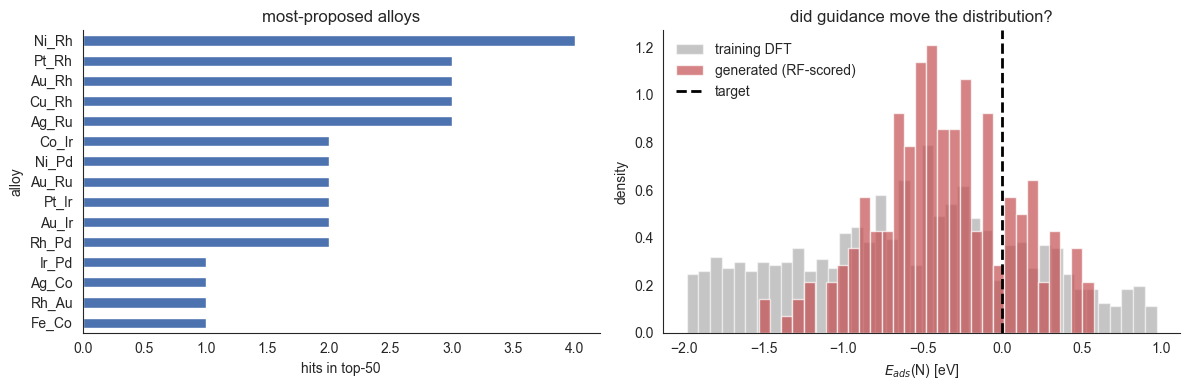

training mean |E - target| : 0.755 eV
generated mean |E - target| : 0.464 eV


In [20]:
# which alloys does the guided diffusion model keep proposing?
top = cand.head(50)
counts = top.alloy.value_counts().head(15)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
counts.iloc[::-1].plot.barh(ax=ax[0], color="#4C72B0")
ax[0].set_xlabel("hits in top-50"); ax[0].set_title("most-proposed alloys")

ax[1].hist(bi_train_data_Y, bins=40, density=True, alpha=.5, label="training DFT", color="#8C8C8C")
ax[1].hist(rf_pred, bins=30, density=True, alpha=.7, label="generated (RF-scored)", color="#C44E52")
ax[1].axvline(TARGET_NADS, color="k", ls="--", lw=2, label="target")
ax[1].set_xlabel("$E_{ads}$(N) [eV]"); ax[1].set_ylabel("density"); ax[1].legend(frameon=False)
ax[1].set_title("did guidance move the distribution?")
sns.despine(fig); plt.tight_layout(); plt.show()

print(f"training mean |E - target| : {np.abs(bi_train_data_Y - TARGET_NADS).mean():.3f} eV")
print(f"generated mean |E - target| : {cand.abs_err_target.mean():.3f} eV")

### Sweeping the target energyThe generator is conditional, so the same trained model can be aimed at any binding strength -useful because the true optimum for N<sub>2</sub> activation sits near the top of the volcano ratherthan exactly at 0 eV.

target -1.50 eV -> generated mean -1.049 +/- 0.450 eV


target -1.00 eV -> generated mean -0.830 +/- 0.427 eV


target -0.50 eV -> generated mean -0.576 +/- 0.391 eV


target +0.00 eV -> generated mean -0.380 +/- 0.415 eV


target +0.50 eV -> generated mean -0.235 +/- 0.412 eV


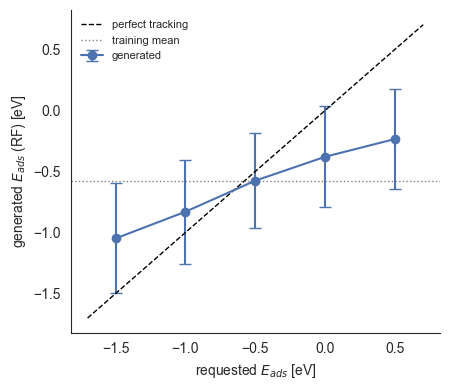

,target,mean_RF,std_RF,frac_within_0p2
0,-1.5,-1.049,0.450,0.350
1,-1.0,-0.830,0.427,0.250
2,-0.5,-0.576,0.391,0.462
3,0.0,-0.380,0.415,0.175
4,0.5,-0.235,0.412,0.125


In [21]:
SWEEP = [-1.5, -1.0, -0.5, 0.0, 0.5]
sweep_rows = []
for tgt in SWEEP:
    g = sample(model, schedule, 80, target=tgt, guidance_scale=GUIDANCE_SCALE, seed=SEED)
    ph = scaler.inverse_transform(g)
    vs = np.array([decode(v)[0] for v in ph])
    p  = rf_nads.predict(scaler.transform(vs))
    sweep_rows.append(dict(target=tgt, mean_RF=p.mean(), std_RF=p.std(),
                           frac_within_0p2=float(np.mean(np.abs(p-tgt) < 0.2))))
    print(f"target {tgt:+.2f} eV -> generated mean {p.mean():+.3f} +/- {p.std():.3f} eV")

sweep = pd.DataFrame(sweep_rows)
fig, ax = plt.subplots(figsize=(4.6,4))
ax.errorbar(sweep.target, sweep.mean_RF, yerr=sweep.std_RF, fmt="o-", capsize=4, color="#4C72B0",
            label="generated")
ax.plot([-1.7,.7], [-1.7,.7], "k--", lw=1, label="perfect tracking")
ax.axhline(bi_train_data_Y.mean(), color="grey", ls=":", lw=1, label="training mean")
ax.set_xlabel("requested $E_{ads}$ [eV]"); ax.set_ylabel("generated $E_{ads}$ (RF) [eV]")
ax.legend(frameon=False, fontsize=8); sns.despine(fig); plt.tight_layout(); plt.show()
sweep.round(3)

The response is monotonic but **shrunk toward the training mean** - a 2 eV swing in the requestproduces roughly 0.8 eV of movement. That is expected and is not a bug to tune away: guidance pullsagainst the learned prior, and the score here comes from the *independent* forest rather than thesurrogate doing the pulling. Raising `GUIDANCE_SCALE` extends the range but pushes samples off thedata manifold, where neither property model is trustworthy. The cell below shows that trade-offexplicitly - pick a scale where diversity and spread are still healthy.

In [22]:
rows = []
for gs in [0.0, 1.0, 3.0, 10.0, 30.0, 100.0]:
    g = sample(model, schedule, 80, target=TARGET_NADS, guidance_scale=gs, seed=SEED)
    ph = scaler.inverse_transform(g)
    vs = np.array([decode(v)[0] for v in ph])
    p  = rf_nads.predict(scaler.transform(vs))
    pairs = {decode(v)[1]["alloy"] for v in ph}
    rows.append(dict(guidance=gs, sample_std=g.std(), sample_max=g.max(),
                     mean_RF=p.mean(), distinct_alloys=len(pairs)))
pd.DataFrame(rows).round(3)

,guidance,sample_std,sample_max,mean_RF,distinct_alloys
0,0.0,0.892,5.146,-0.634,63
1,1.0,0.890,5.061,-0.486,56
2,3.0,0.886,5.061,-0.428,55
3,10.0,0.875,5.070,-0.380,54
4,30.0,0.874,5.096,-0.318,57
5,100.0,0.878,4.881,-0.311,63


---## 9. What ran, and what it means* `Nads_opt.pkl` is reproduced and validated against the correct `StandardScaler`.* The diffusion model trains on the real 30-dim features (the published code could not) and is  trained long enough to converge - verified in 6b against the training distribution, not just by  a falling loss curve.* The property-guidance term actually carries gradient, via a surrogate; the forest scores  candidates independently.* Samples are decoded into named alloys with valid compositions and tabulated descriptors.**The two changes that mattered most** were not the syntax errors. Fixing only those still yields amodel that emits nonsense: the published `EPOCHS = 50` is 350 gradient steps (diverged reverseprocess), and `lambda_cond = 10.0` applied to an unclipped $\hat{x}_0$ collapses every sample onto onealloy. Anyone reproducing this paper's method should check sample spread against the training databefore trusting any generated candidate.**Caveats worth stating in any write-up.** The RF and the surrogate are correlated - they were fiton the same 1364 sites - so `model_spread` is a weak uncertainty estimate; anything the generatorproposes is a *hypothesis for DFT*, not a validated catalyst. The decoder also treats`filling_a..d` as free coordinates, whereas in reality they follow from the surface structure, so`fill_dist_to_nearest_real` should be small for a candidate to be trustworthy.Outputs are written to `outputs/generated_candidates.csv` and `outputs/generated_features.npy`;diffusion checkpoints to `checkpoints/`.---### Next: the battery projectThe same architecture transfers by swapping three things - the feature block, the target property,and the decoder. Everything from Section 4 onward is property-agnostic.